# Iterated Residual KF Notebook

這份 notebook 專門用來做「逐層 Kalman filter 殘差分解」：每一層都看點估計與 95% 區間，最後把各層結果相加，觀察整體預測表現。


In [1]:
import matplotlib
import numpy as np
import time
import random
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import pandas as pd
from IPython.display import display, Image

np.random.seed(2026)
random.seed(2026)
torch.manual_seed(2026)


## 工具函式

先定義相關性摘要、Kalman filter 與單步分解工具。


In [35]:
def component_correlation_summary(linear_part, nonlinear_part):
    linear_part = np.asarray(linear_part, dtype=float)
    nonlinear_part = np.asarray(nonlinear_part, dtype=float)

    if linear_part.shape != nonlinear_part.shape:
        raise ValueError("linear_part and nonlinear_part must have the same shape.")

    if linear_part.size < 2:
        return {
            "pearson_corr": np.nan,
            "abs_pearson_corr": np.nan,
            "corr_sq": np.nan,
            "covariance": np.nan,
        }

    pearson_corr = float(np.corrcoef(linear_part, nonlinear_part)[0, 1])
    covariance = float(np.cov(linear_part, nonlinear_part, ddof=1)[0, 1])
    return {
        "pearson_corr": pearson_corr,
        "abs_pearson_corr": abs(pearson_corr),
        "corr_sq": pearson_corr ** 2,
        "covariance": covariance,
    }


def kalman_filter(observations, process_variance=0.5, measurement_variance=10.0, initial_error=1.0):
    initial_estimate = float(observations[0])
    estimated_state = initial_estimate
    estimate_error = float(initial_error)
    estimated_states = []

    for measurement in observations:
        predicted_state = estimated_state
        predicted_error = estimate_error + process_variance

        kalman_gain = predicted_error / (predicted_error + measurement_variance)
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)
        estimate_error = (1.0 - kalman_gain) * predicted_error
        estimated_states.append(estimated_state)

    return np.array(estimated_states, dtype=float)


def decompose_with_simple_kf(series, process_variance=0.5, measurement_variance=10.0):
    estimated_low = kalman_filter(
        series,
        process_variance=process_variance,
        measurement_variance=measurement_variance,
        initial_error=1.0,
    )
    estimated_high = np.asarray(series, dtype=float) - estimated_low
    return estimated_low, estimated_high


## Joint DistPred 模型

沿用原本的 recursive joint DistPred 架構，對每一層的 low / residual 一起做預測。


In [36]:
def create_joint_windows(low_series, high_series, window_size):
    features = []
    targets = []
    for idx in range(window_size, len(low_series)):
        low_window = np.asarray(low_series[idx - window_size:idx], dtype=float)
        high_window = np.asarray(high_series[idx - window_size:idx], dtype=float)
        joint_window = np.column_stack([low_window, high_window]).reshape(-1)
        features.append(joint_window)
        targets.append([float(low_series[idx]), float(high_series[idx])])
    return np.asarray(features, dtype=float), np.asarray(targets, dtype=float)


class JointDistPredMLP(nn.Module):
    def __init__(self, input_dim, ensemble_size):
        super().__init__()
        self.ensemble_size = ensemble_size
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, ensemble_size * 2),
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1, self.ensemble_size, 2)


def joint_distpred_loss(pred_ensemble, y_true):
    y_true = y_true.unsqueeze(1)
    calibration_term = torch.abs(pred_ensemble - y_true).mean(dim=(1, 2))
    pairwise = pred_ensemble.unsqueeze(2) - pred_ensemble.unsqueeze(1)
    diversity_term = torch.abs(pairwise).mean(dim=(1, 2, 3))
    mean_term = torch.square(pred_ensemble.mean(dim=1) - y_true.squeeze(1)).mean(dim=1)
    return (calibration_term - 0.5 * diversity_term + 0.05 * mean_term).mean()


def fit_joint_distpred_bundle(low_train, high_train, window_size, ensemble_size=50, epochs=250, learning_rate=1e-3):
    x_train, y_train = create_joint_windows(low_train, high_train, window_size)
    if len(x_train) == 0:
        raise ValueError("Not enough samples for joint DistPred windows.")

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    x_train_scaled = x_scaler.fit_transform(x_train)
    y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

    x_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

    model = JointDistPredMLP(input_dim=x_train.shape[1], ensemble_size=ensemble_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        pred_ensemble = model(x_tensor)
        loss = joint_distpred_loss(pred_ensemble, y_tensor)
        loss.backward()
        optimizer.step()

    low_q = np.quantile(low_train, [0.01, 0.99])
    high_q = np.quantile(high_train, [0.01, 0.99])
    low_iqr = np.subtract(*np.quantile(low_train, [0.75, 0.25]))
    high_iqr = np.subtract(*np.quantile(high_train, [0.75, 0.25]))
    low_margin = max(0.5 * low_iqr, 0.25)
    high_margin = max(0.5 * high_iqr, 0.25)
    clip_bounds = (
        (float(low_q[0] - low_margin), float(low_q[1] + low_margin)),
        (float(high_q[0] - high_margin), float(high_q[1] + high_margin)),
    )

    return {
        "model": model.eval(),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "clip_bounds": clip_bounds,
        "window_size": window_size,
        "ensemble_size": ensemble_size,
    }


def recursive_joint_distpred_forecast(bundle, low_history, high_history, horizon, window_size):
    ensemble_size = bundle["ensemble_size"]
    low_hist = np.asarray(low_history[-window_size:], dtype=float)
    high_hist = np.asarray(high_history[-window_size:], dtype=float)
    base_history = np.column_stack([low_hist, high_hist])
    rolling_histories = np.tile(base_history.reshape(1, window_size, 2), (ensemble_size, 1, 1))
    low_paths = np.zeros((ensemble_size, horizon), dtype=float)
    high_paths = np.zeros((ensemble_size, horizon), dtype=float)

    for step_idx in range(horizon):
        features = rolling_histories.reshape(ensemble_size, window_size * 2)
        features_scaled = bundle["x_scaler"].transform(features)
        with torch.no_grad():
            pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

        diag_scaled = pred_scaled[np.arange(ensemble_size), np.arange(ensemble_size), :]
        diag_pred = bundle["y_scaler"].inverse_transform(diag_scaled)
        next_low = np.clip(diag_pred[:, 0], bundle["clip_bounds"][0][0], bundle["clip_bounds"][0][1])
        next_high = np.clip(diag_pred[:, 1], bundle["clip_bounds"][1][0], bundle["clip_bounds"][1][1])

        low_paths[:, step_idx] = next_low
        high_paths[:, step_idx] = next_high

        next_pair = np.stack([next_low, next_high], axis=1).reshape(ensemble_size, 1, 2)
        rolling_histories = np.concatenate([rolling_histories[:, 1:, :], next_pair], axis=1)

    return low_paths, high_paths


def fit_joint_distpred_component(low_train, high_train, horizon, window_size, ensemble_size=50):
    bundle = fit_joint_distpred_bundle(low_train, high_train, window_size, ensemble_size=ensemble_size)
    low_samples, high_samples = recursive_joint_distpred_forecast(bundle, low_train, high_train, horizon, window_size)
    low_forecast = np.mean(low_samples, axis=0)
    high_forecast = np.mean(high_samples, axis=0)
    return low_forecast, high_forecast, low_samples, high_samples, bundle


## 模擬資料

這裡改用 Giordano 風格的模擬資料：線性 part 帶有 AR 結構，非線性 part 則由前一期狀態經過非線性轉換後生成，再加上量測雜訊。這樣可以直接比較同一個逐層 KF 流程在不同資料生成機制下的表現。


In [37]:
def simulate_giordano_style_data(n_steps, noise_std=0.15):
    low_true = np.zeros(n_steps, dtype=float)
    high_true = np.zeros(n_steps, dtype=float)

    low_true[0] = np.random.normal(0, 1.0)
    high_true[0] = np.random.normal(0, 0.5)
    high_true[1] = np.random.normal(0, 0.5)

    for idx in range(1, n_steps):
        shared_error = np.random.normal(0, 1.0)
        low_true[idx] = 0.6 * low_true[idx - 1] + shared_error

        if idx < 2:
            continue

        coeff_1 = 0.5 + 0.9 * np.exp(-(high_true[idx - 1] ** 2))
        coeff_2 = -0.8 - 1.8 * np.exp(-(high_true[idx - 1] ** 2))
        high_true[idx] = (
            coeff_1 * high_true[idx - 1]
            + coeff_2 * high_true[idx - 2]
            + shared_error
        )

    noise = np.random.normal(0, noise_std, size=n_steps)
    measurements = low_true + high_true + noise
    return low_true, high_true, measurements


## 逐層 KF + 殘差預測流程

每一層都對「上一層殘差」做 KF，接著對該層的 `low / residual` 做 recursive joint DistPred 預測。最後可以把前幾層結果逐步相加。


In [38]:
def run_iterated_residual_experiment(
    train_size=300,
    horizon=20,
    n_layers=5,
    window_size=15,
    ensemble_size=50,
    process_variance=0.5,
    measurement_variance=10.0,
    seed=42,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    low_true, high_true, measurements = simulate_giordano_style_data(train_size + horizon)
    measurements = np.asarray(measurements, dtype=float)
    actual_test = measurements[train_size:]

    current_residual_full = measurements.copy()
    accumulated_low_samples = None
    layer_results = []

    for layer_idx in range(1, n_layers + 1):
        estimated_low_full, estimated_high_full = decompose_with_simple_kf(
            current_residual_full,
            process_variance=process_variance,
            measurement_variance=measurement_variance,
        )

        estimated_low_train = estimated_low_full[:train_size]
        estimated_high_train = estimated_high_full[:train_size]
        layer_target_test = current_residual_full[train_size:]

        low_forecast, high_forecast, low_samples, high_samples, bundle = fit_joint_distpred_component(
            estimated_low_train,
            estimated_high_train,
            horizon,
            window_size=window_size,
            ensemble_size=ensemble_size,
        )

        layer_final_samples = low_samples + high_samples
        layer_final_forecast = np.mean(layer_final_samples, axis=0)
        layer_interval_lower = np.quantile(layer_final_samples, 0.025, axis=0)
        layer_interval_upper = np.quantile(layer_final_samples, 0.975, axis=0)

        if accumulated_low_samples is None:
            cumulative_samples = layer_final_samples.copy()
        else:
            cumulative_samples = accumulated_low_samples + layer_final_samples
        cumulative_forecast = np.mean(cumulative_samples, axis=0)
        cumulative_lower = np.quantile(cumulative_samples, 0.025, axis=0)
        cumulative_upper = np.quantile(cumulative_samples, 0.975, axis=0)

        layer_corr = component_correlation_summary(estimated_low_train, estimated_high_train)
        low_sample_width = float(np.mean(np.quantile(low_samples, 0.975, axis=0) - np.quantile(low_samples, 0.025, axis=0)))
        high_sample_width = float(np.mean(np.quantile(high_samples, 0.975, axis=0) - np.quantile(high_samples, 0.025, axis=0)))
        final_sample_width = float(np.mean(np.quantile(layer_final_samples, 0.975, axis=0) - np.quantile(layer_final_samples, 0.025, axis=0)))

        layer_point_mse = float(np.mean((layer_final_forecast - layer_target_test) ** 2))
        layer_interval_width = float(np.mean(layer_interval_upper - layer_interval_lower))
        layer_coverage = float(np.mean((layer_target_test >= layer_interval_lower) & (layer_target_test <= layer_interval_upper)) * 100)
        cumulative_point_mse = float(np.mean((cumulative_forecast - actual_test) ** 2))
        cumulative_interval_width = float(np.mean(cumulative_upper - cumulative_lower))
        cumulative_coverage = float(np.mean((actual_test >= cumulative_lower) & (actual_test <= cumulative_upper)) * 100)

        layer_results.append({
            "layer": layer_idx,
            "train_low": estimated_low_train,
            "train_residual": estimated_high_train,
            "bundle": bundle,
            "low_samples": low_samples,
            "high_samples": high_samples,
            "layer_target_test": layer_target_test,
            "layer_forecast": layer_final_forecast,
            "layer_samples": layer_final_samples,
            "layer_interval_lower": layer_interval_lower,
            "layer_interval_upper": layer_interval_upper,
            "layer_point_mse": layer_point_mse,
            "layer_rmse": float(np.sqrt(layer_point_mse)),
            "layer_interval_width": layer_interval_width,
            "layer_coverage": layer_coverage,
            "layer_coverage_gap": float(layer_coverage - 95.0),
            "layer_width_to_rmse": float(layer_interval_width / max(np.sqrt(layer_point_mse), 1e-8)),
            "low_sample_width": low_sample_width,
            "high_sample_width": high_sample_width,
            "final_sample_width": final_sample_width,
            "cumulative_forecast": cumulative_forecast,
            "cumulative_samples": cumulative_samples.copy(),
            "cumulative_interval_lower": cumulative_lower,
            "cumulative_interval_upper": cumulative_upper,
            "cumulative_point_mse": cumulative_point_mse,
            "cumulative_rmse": float(np.sqrt(cumulative_point_mse)),
            "cumulative_interval_width": cumulative_interval_width,
            "cumulative_coverage": cumulative_coverage,
            "cumulative_coverage_gap": float(cumulative_coverage - 95.0),
            "cumulative_width_to_rmse": float(cumulative_interval_width / max(np.sqrt(cumulative_point_mse), 1e-8)),
            "residual_corr": layer_corr,
        })

        accumulated_low_samples = low_samples if accumulated_low_samples is None else accumulated_low_samples + low_samples
        current_residual_full = estimated_high_full

    return {
        "data": {
            "low_true": low_true,
            "high_true": high_true,
            "measurements": measurements,
        },
        "train_size": train_size,
        "horizon": horizon,
        "actual_test": actual_test,
        "layer_results": layer_results,
    }


## 結果摘要表

這張表會同時整理兩種角度：`layer_only` 是拿該層自己的 residual target 來評估點預測與 95% 區間；`cumulative` 則是把前面各層抽出的 low component 累加，再加上目前這一層的 residual forecast，最後和原始 observation 做比較。


In [39]:
train_size = 300
horizon = 25
n_layers = 10
window_size = 15
ensemble_size = 50
base_seed = 42
n_monte_carlo = 50

summary_rows = []
representative_experiment = None

for mc_idx in range(n_monte_carlo):
    current_experiment = run_iterated_residual_experiment(
        train_size=train_size,
        horizon=horizon,
        n_layers=n_layers,
        window_size=window_size,
        ensemble_size=ensemble_size,
        seed=base_seed + mc_idx,
    )

    if representative_experiment is None:
        representative_experiment = current_experiment

    for layer in current_experiment["layer_results"]:
        corr = layer["residual_corr"]
        summary_rows.append({
            "layer": layer["layer"],
            "mode": "layer_only",
            "point_mse": layer["layer_point_mse"],
            "rmse": layer["layer_rmse"],
            "coverage": layer["layer_coverage"],
            "coverage_gap": layer["layer_coverage_gap"],
            "interval_width": layer["layer_interval_width"],
            "width_to_rmse": layer["layer_width_to_rmse"],
            "low_sample_width": layer["low_sample_width"],
            "high_sample_width": layer["high_sample_width"],
            "final_sample_width": layer["final_sample_width"],
            "corr": corr["pearson_corr"],
            "abs_corr": corr["abs_pearson_corr"],
            "corr_sq": corr["corr_sq"],
        })
        summary_rows.append({
            "layer": layer["layer"],
            "mode": "cumulative",
            "point_mse": layer["cumulative_point_mse"],
            "rmse": layer["cumulative_rmse"],
            "coverage": layer["cumulative_coverage"],
            "coverage_gap": layer["cumulative_coverage_gap"],
            "interval_width": layer["cumulative_interval_width"],
            "width_to_rmse": layer["cumulative_width_to_rmse"],
            "low_sample_width": layer["low_sample_width"],
            "high_sample_width": layer["high_sample_width"],
            "final_sample_width": layer["final_sample_width"],
            "corr": corr["pearson_corr"],
            "abs_corr": corr["abs_pearson_corr"],
            "corr_sq": corr["corr_sq"],
        })

summary_df = (
    pd.DataFrame(summary_rows)
    .groupby(["layer", "mode"], as_index=False)
    .mean(numeric_only=True)
)
display(summary_df.round(4))
print(f"Monte Carlo runs: {n_monte_carlo}")

# 保留第一個 run 給後續圖形診斷使用
experiment = representative_experiment


,layer,mode,point_mse,rmse,coverage,coverage_gap,interval_width,width_to_rmse,low_sample_width,high_sample_width,final_sample_width,corr,abs_corr,corr_sq
0,1,cumulative,32.4121,5.3150,94.24,-0.76,28.0087,5.9174,7.8249,23.9449,28.0087,0.4771,0.4771,0.2282
1,1,layer_only,32.4121,5.3150,94.24,-0.76,28.0087,5.9174,7.8249,23.9449,28.0087,0.4771,0.4771,0.2282
2,2,cumulative,32.7878,5.3606,92.56,-2.44,22.5870,4.7231,4.6860,19.4663,21.6239,0.5489,0.5489,0.3014
3,2,layer_only,23.7301,4.5418,94.40,-0.60,21.6239,5.3626,4.6860,19.4663,21.6239,0.5489,0.5489,0.3014
4,3,cumulative,32.7552,5.3018,90.80,-4.20,20.5391,4.4687,3.7982,16.9869,18.7551,0.5701,0.5701,0.3251
5,3,layer_only,17.9764,3.8900,94.32,-0.68,18.7551,5.6630,3.7982,16.9869,18.7551,0.5701,0.5701,0.3251
6,4,cumulative,32.3216,5.2689,87.52,-7.48,18.6215,4.0556,3.2353,14.7194,16.2493,0.5801,0.5801,0.3366
7,4,layer_only,13.5036,3.3697,93.60,-1.40,16.2493,5.6946,3.2353,14.7194,16.2493,0.5801,0.5801,0.3366
8,5,cumulative,32.6429,5.3015,86.96,-8.04,17.1567,3.7013,2.7884,12.9954,14.2562,0.5861,0.5861,0.3435
9,5,layer_only,10.4408,2.9724,94.32,-0.68,14.2562,5.6015,2.7884,12.9954,14.2562,0.5861,0.5861,0.3435


Monte Carlo runs: 50


## 第一層 Sample 診斷圖

把第 1 層的 `low / residual / final` sample band 分開畫出來，方便直接看是哪一個部分先把區間撐寬。


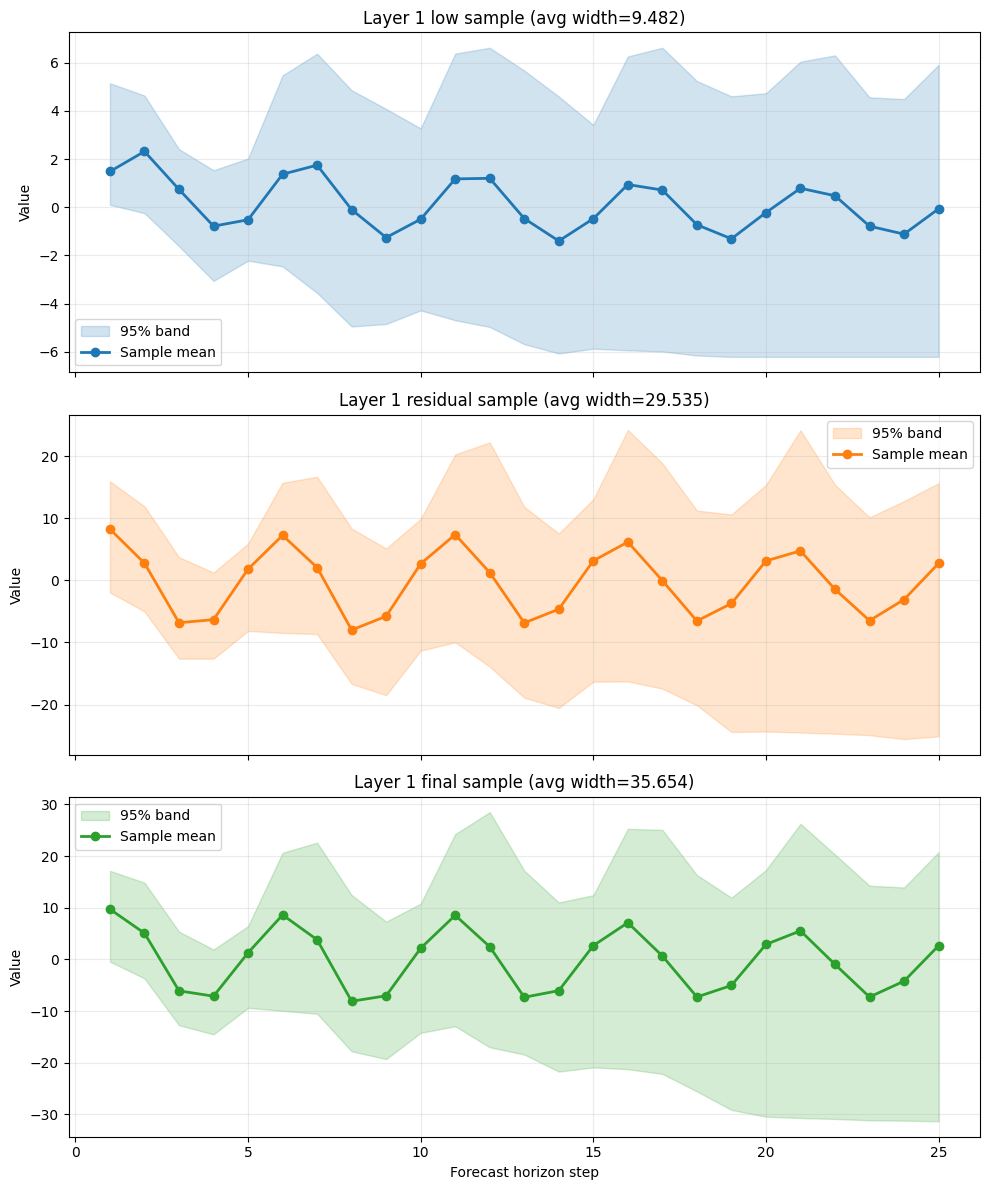

In [42]:
layer1 = experiment["layer_results"][0]
steps = np.arange(1, layer1["layer_samples"].shape[1] + 1)

diagnostic_specs = [
    ("low sample", layer1["low_samples"], "tab:blue"),
    ("residual sample", layer1["high_samples"], "tab:orange"),
    ("final sample", layer1["layer_samples"], "tab:green"),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for ax, (label, samples, color) in zip(axes, diagnostic_specs):
    samples = np.asarray(samples, dtype=float)
    sample_mean = np.mean(samples, axis=0)
    lower = np.quantile(samples, 0.025, axis=0)
    upper = np.quantile(samples, 0.975, axis=0)
    width = upper - lower

    ax.fill_between(steps, lower, upper, color=color, alpha=0.20, label="95% band")
    ax.plot(steps, sample_mean, color=color, linewidth=2, marker="o", label="Sample mean")
    ax.set_title(f"Layer 1 {label} (avg width={np.mean(width):.3f})")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Forecast horizon step")
fig.tight_layout()
plt.show()
plt.close(fig)


## 圖：每層自己的區間與累加後的區間

同一層同時畫兩張圖：該層自己的預測區間，以及累加到該層為止的總預測區間。


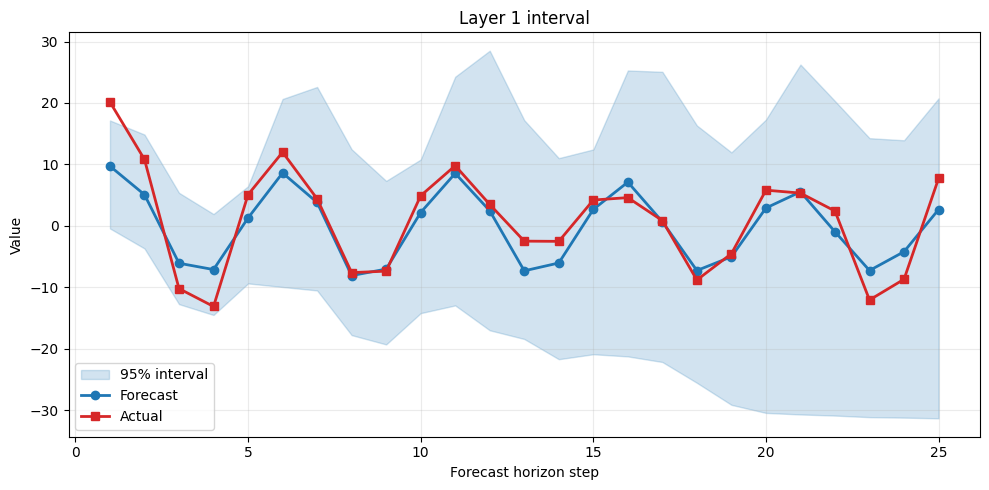

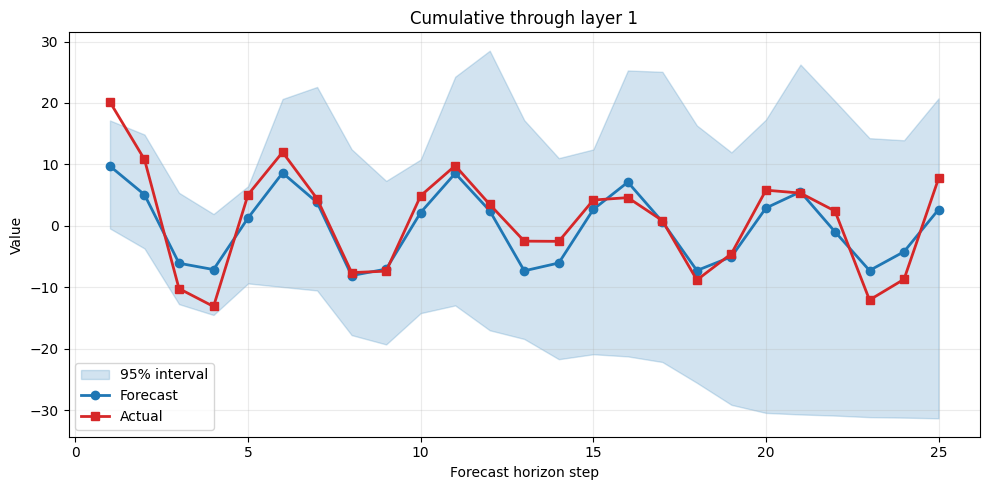

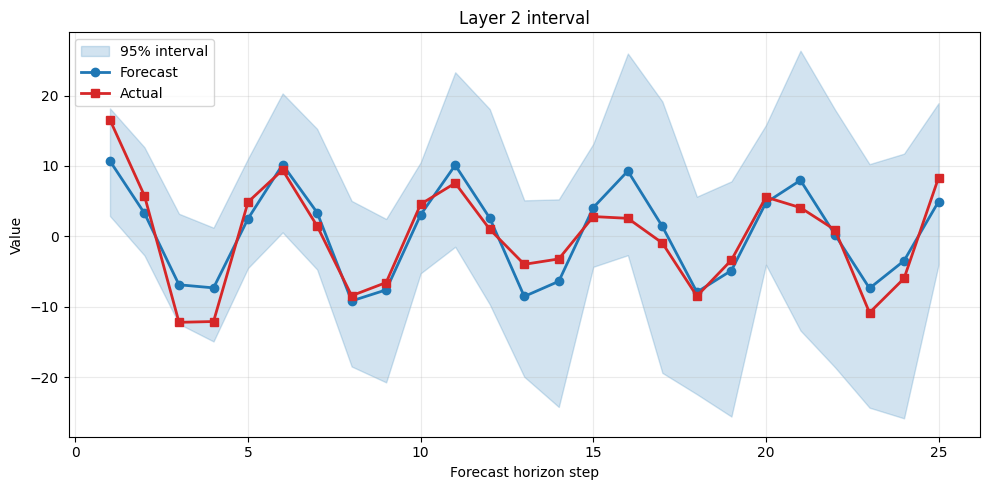

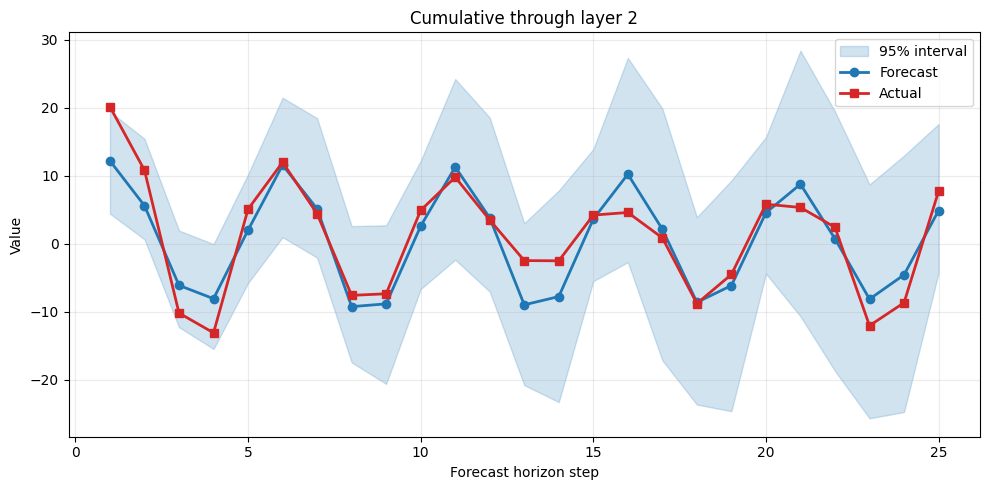

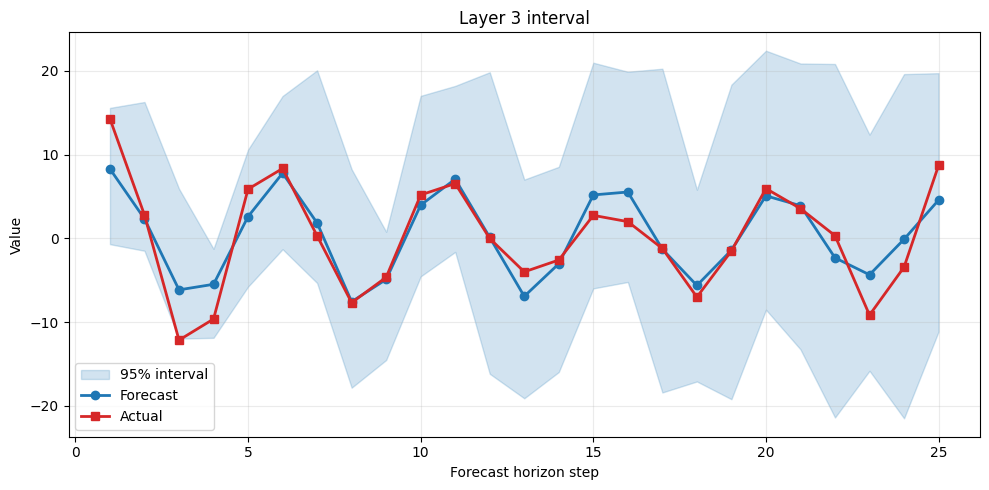

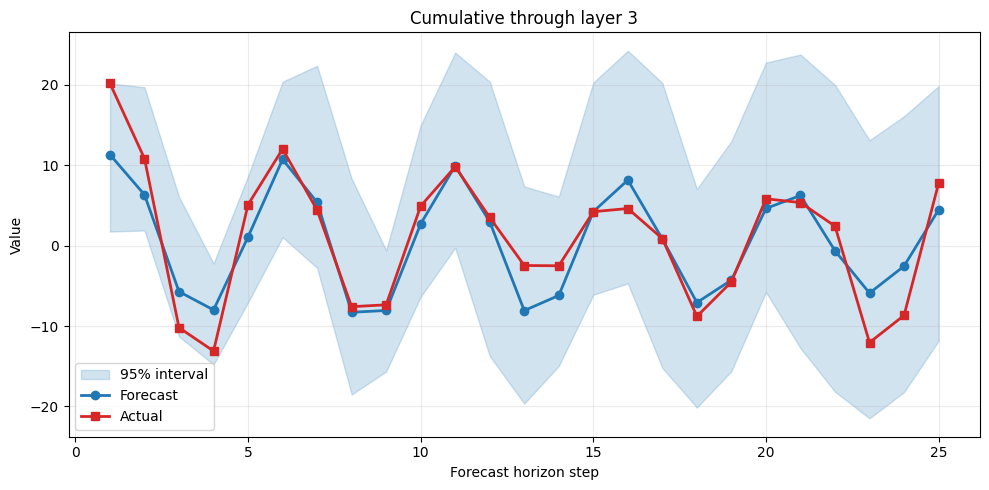

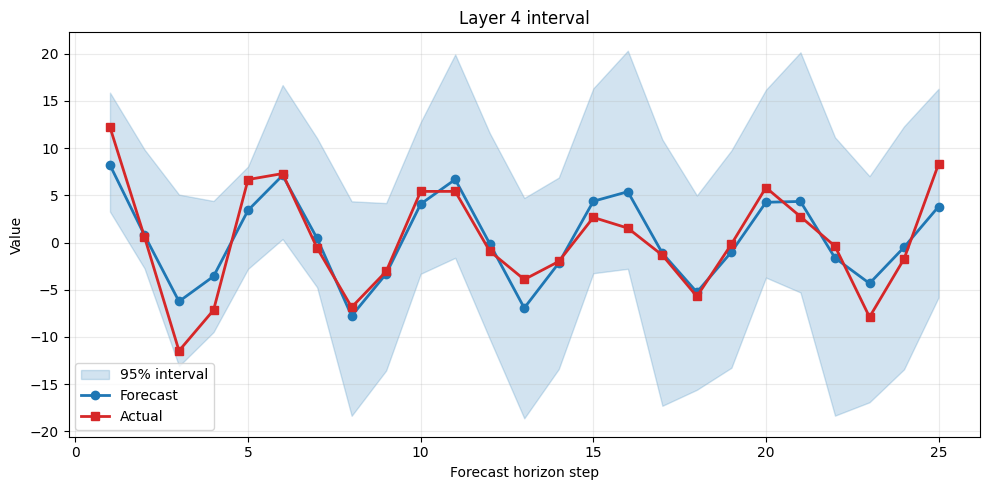

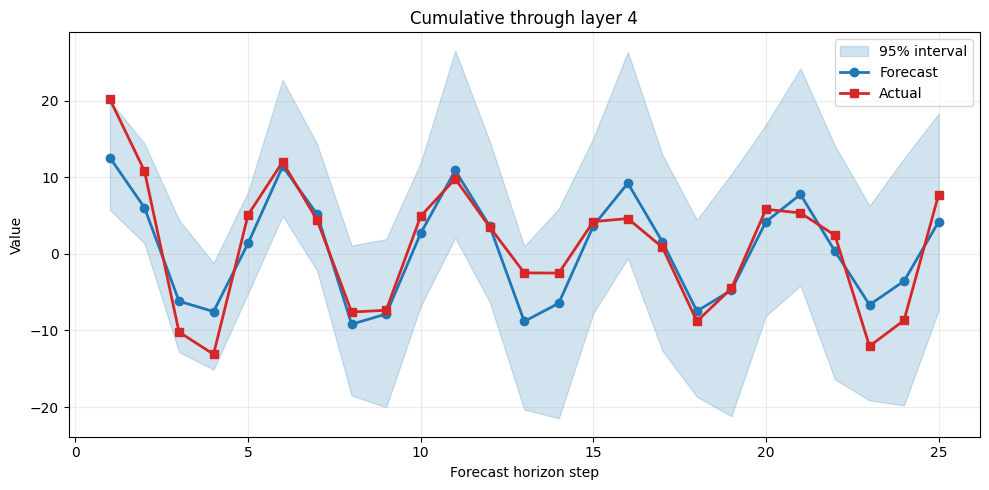

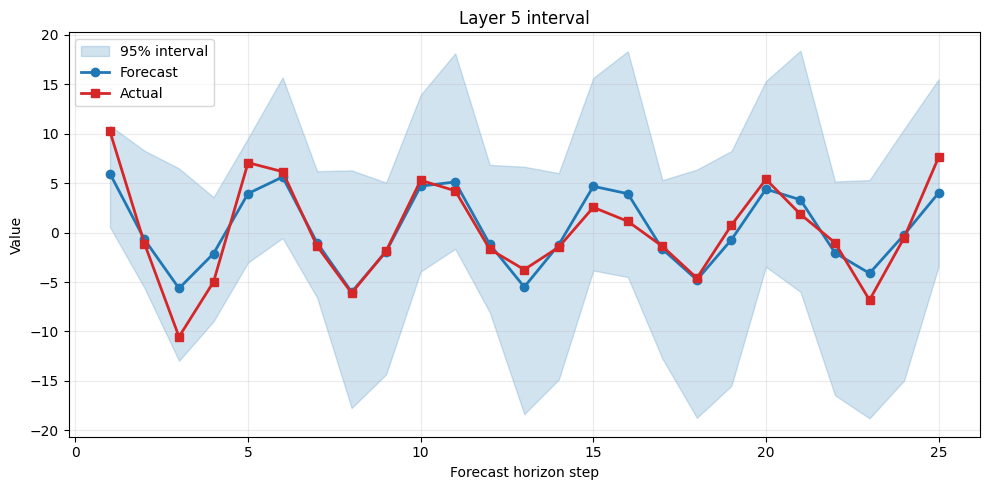

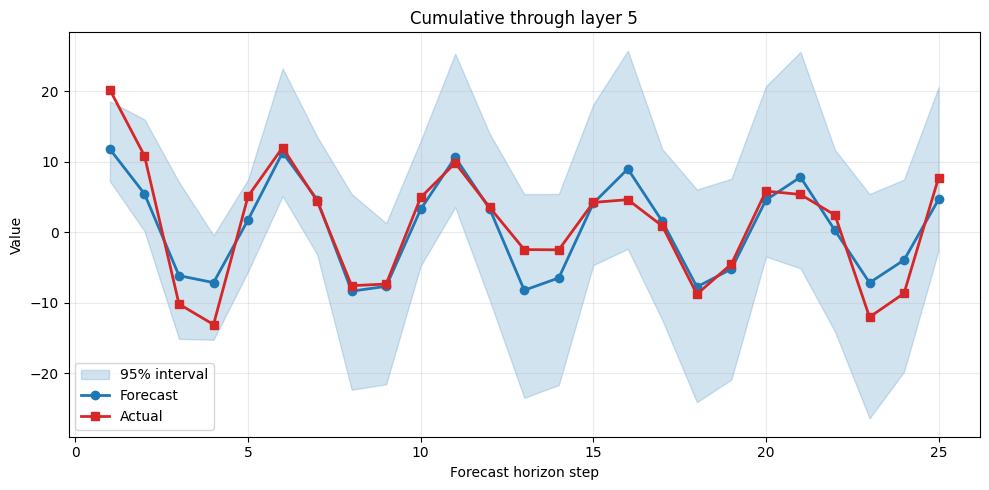

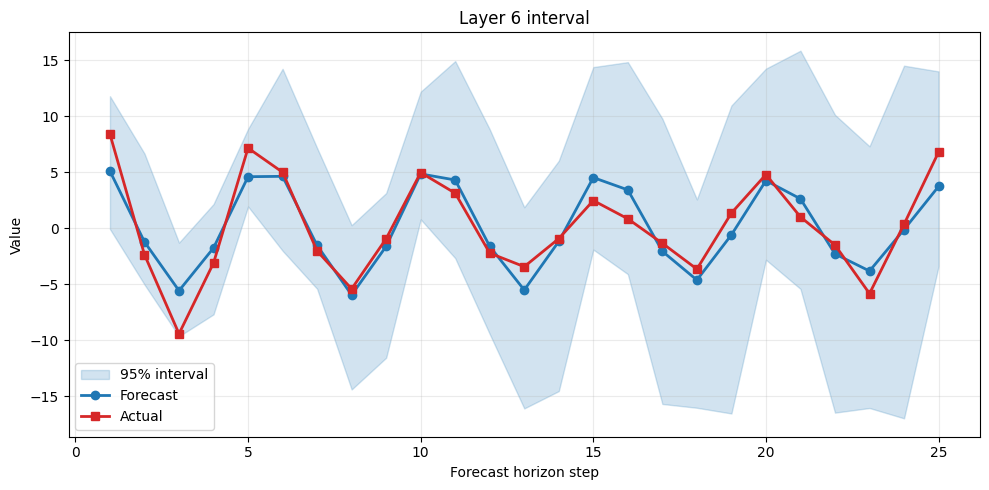

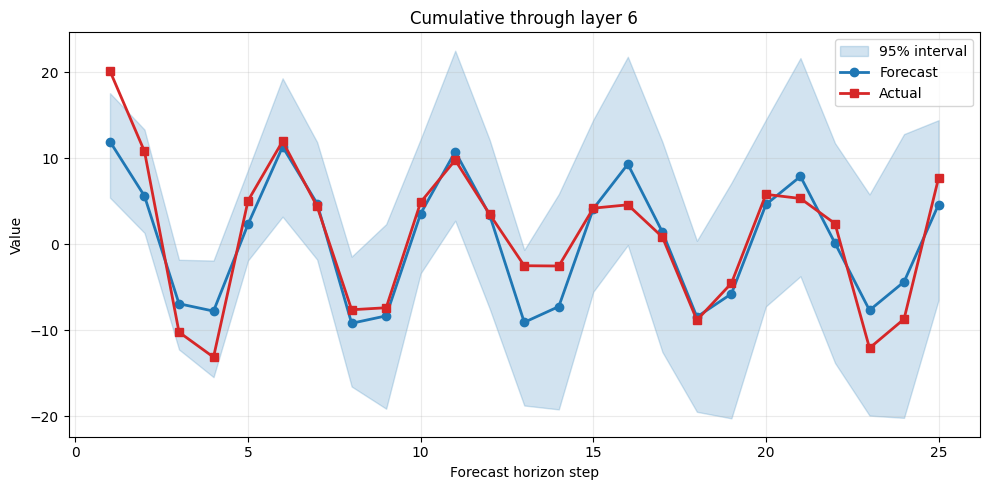

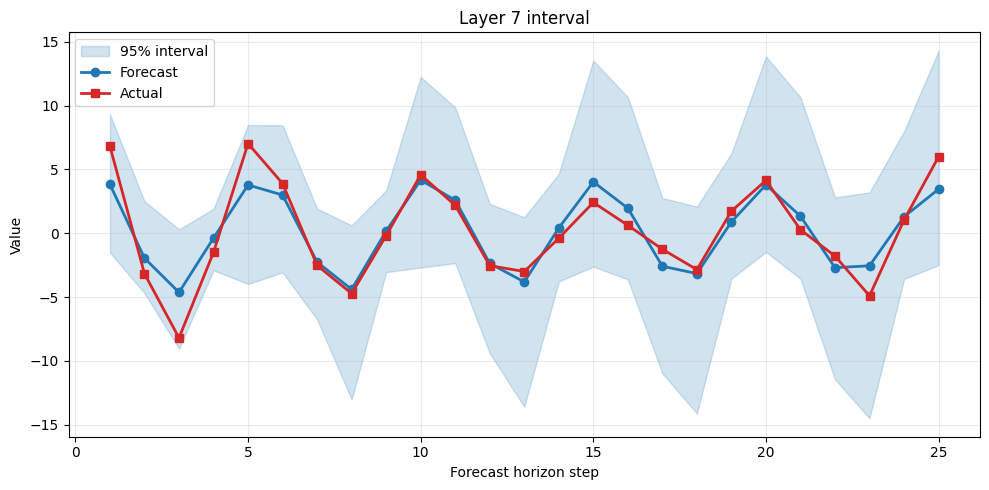

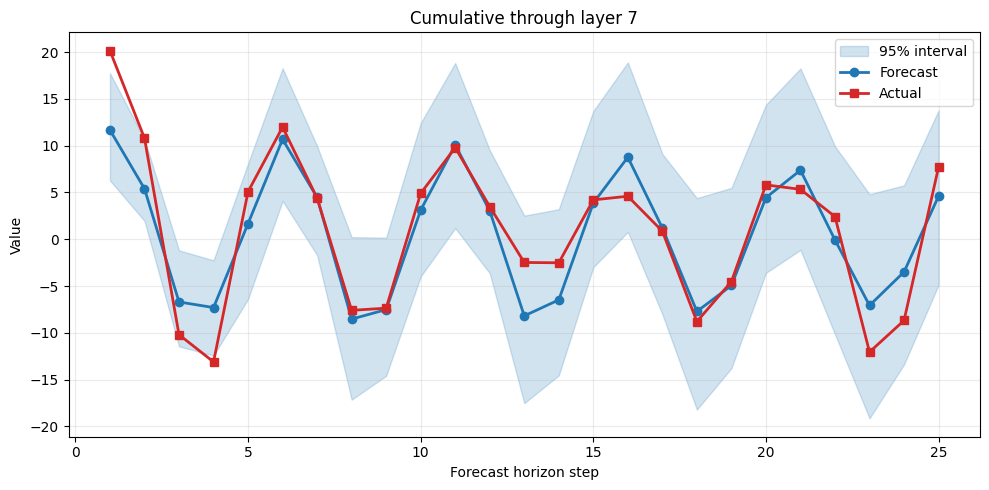

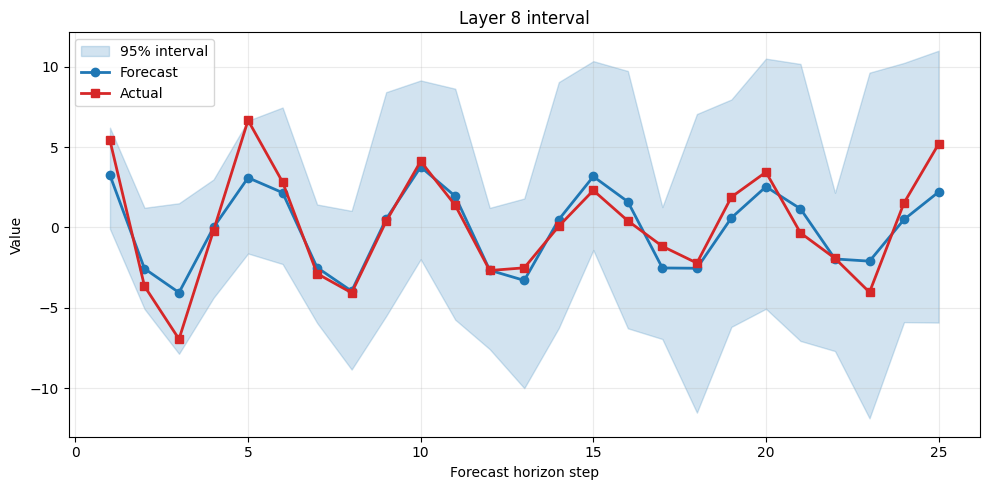

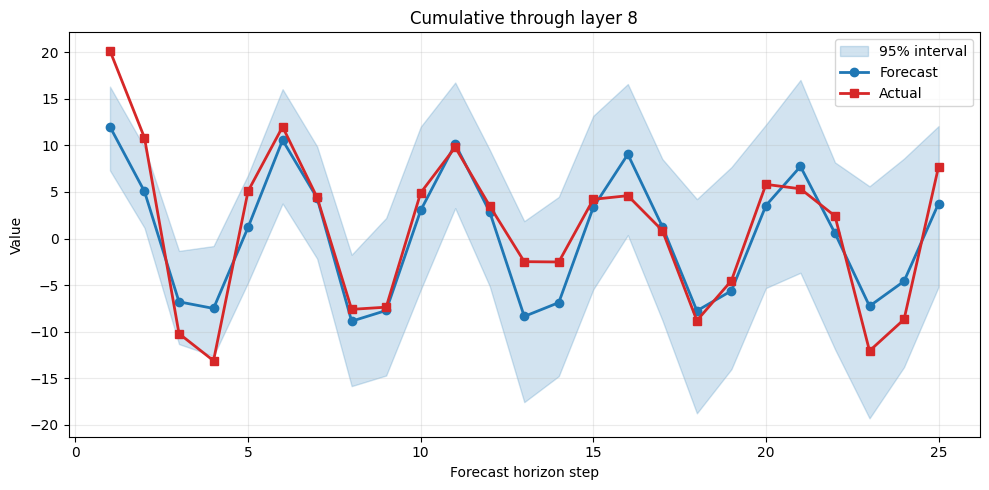

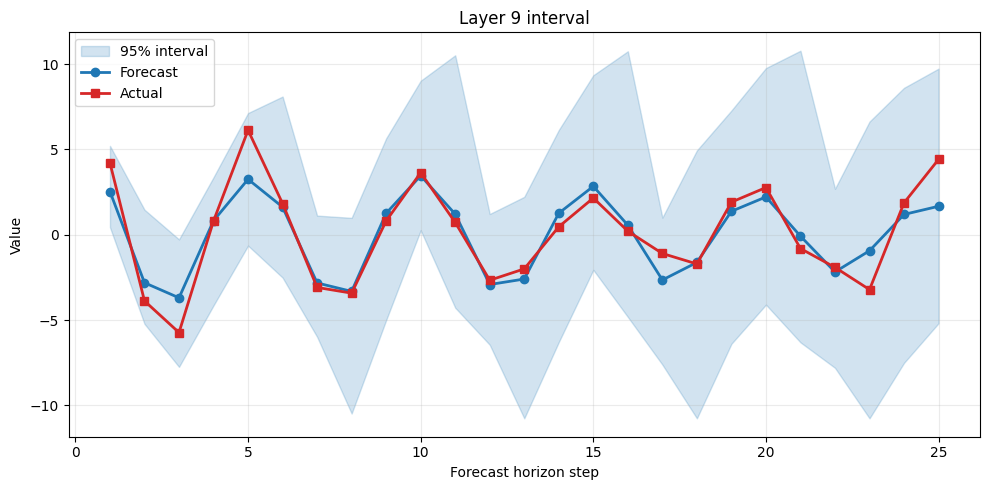

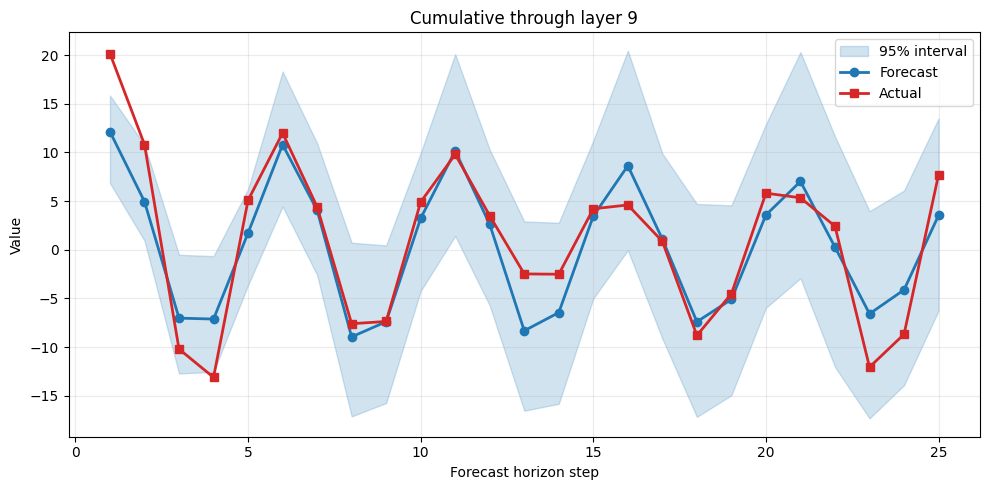

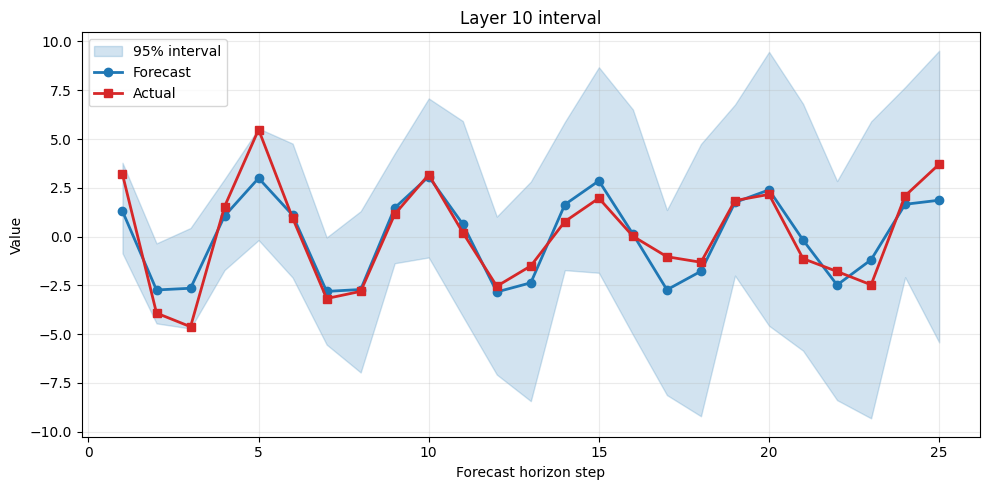

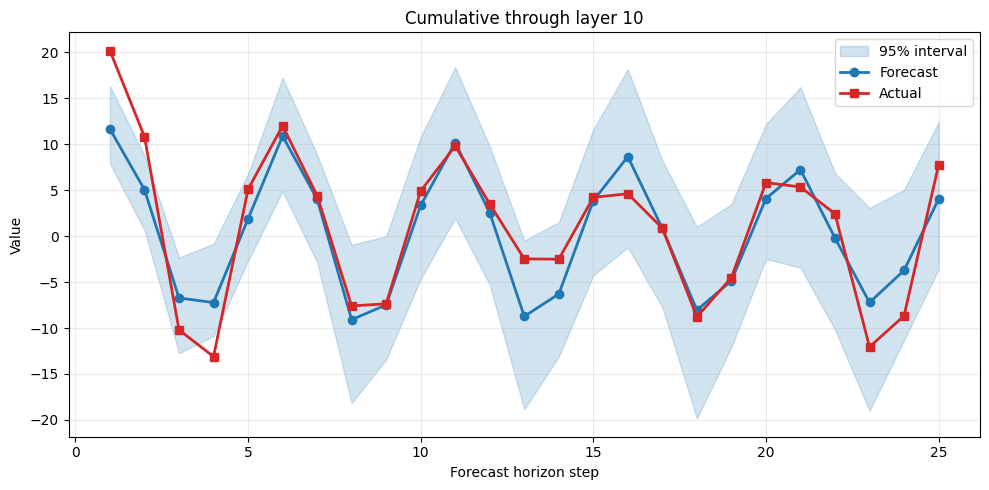

In [43]:
def show_interval_plot(actual, forecast, lower, upper, title):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    steps = np.arange(1, len(actual) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(steps, lower, upper, color="tab:blue", alpha=0.20, label="95% interval")
    ax.plot(steps, forecast, color="tab:blue", linewidth=2, marker="o", label="Forecast")
    ax.plot(steps, actual, color="tab:red", linewidth=2, marker="s", label="Actual")
    ax.set_title(title)
    ax.set_xlabel("Forecast horizon step")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for layer in experiment["layer_results"]:
    layer_idx = layer["layer"]

    show_interval_plot(
        layer["layer_target_test"],
        layer["layer_forecast"],
        layer["layer_interval_lower"],
        layer["layer_interval_upper"],
        title=f"Layer {layer_idx} interval",
    )
    show_interval_plot(
        experiment["actual_test"],
        layer["cumulative_forecast"],
        layer["cumulative_interval_lower"],
        layer["cumulative_interval_upper"],
        title=f"Cumulative through layer {layer_idx}",
    )
